# Phase 3.1.6 — Feature Ablation

Bounded, exploratory check: does min_cv_pitch alone (the dominant
TreeExplainer feature from Phase 3.1.5) capture most of the full
11-feature ensemble's AUC-ROC (0.6033), or do the other 10 features
meaningfully add performance / change which players get flagged?
Exactly 3 new configs are run (1, 2, and 4 features) against the
existing 11-feature reference — no retraining of the reference, no
additional configs.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score

BACKEND_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from core.model import Autoencoder, FEATURE_ORDER, get_cleaned_train_test_data
from core.inference import load_models, score_players

X_train_cleaned, y_train_cleaned, X_test, y_test = get_cleaned_train_test_data()
X_train_legit = X_train_cleaned[y_train_cleaned == 0]

# Verify column order against features_hybrid.csv headers -- do not
# assume the order given in the task brief without checking.
df_headers = pd.read_csv(BACKEND_DIR / "data" / "features_hybrid.csv", nrows=0).columns.tolist()
csv_feature_order = [c for c in df_headers if c in FEATURE_ORDER]

ASSUMED_ORDER = [
    "peak_yaw_delta", "peak_pitch_delta", "mean_yaw_delta", "snap_count",
    "min_cv_yaw", "min_cv_pitch", "cv_yaw_std", "cv_pitch_std",
    "fire_on_target_rate", "yaw_jerk", "engagement_firing_rate",
]

print(f"FEATURE_ORDER (core.model, matches X_train/X_test column order): {FEATURE_ORDER}")
print(f"Assumed order from task brief:                                   {ASSUMED_ORDER}")
print(f"Order assumption matches core.model.FEATURE_ORDER: {FEATURE_ORDER == ASSUMED_ORDER}")

assert FEATURE_ORDER == ASSUMED_ORDER, (
    "Assumed column order does NOT match core.model.FEATURE_ORDER -- "
    "using core.model.FEATURE_ORDER (the array's actual order) below regardless."
)

for i, f in enumerate(FEATURE_ORDER):
    print(f"  {i}: {f}")

print()
print(f"X_train_legit shape: {X_train_legit.shape}")
print(f"X_test shape: {X_test.shape}")

def col(name):
    return FEATURE_ORDER.index(name)

results = []  # collect (config_name, feature_count, feature_names, auc) across cells

FEATURE_ORDER (core.model, matches X_train/X_test column order): ['peak_yaw_delta', 'peak_pitch_delta', 'mean_yaw_delta', 'snap_count', 'min_cv_yaw', 'min_cv_pitch', 'cv_yaw_std', 'cv_pitch_std', 'fire_on_target_rate', 'yaw_jerk', 'engagement_firing_rate']
Assumed order from task brief:                                   ['peak_yaw_delta', 'peak_pitch_delta', 'mean_yaw_delta', 'snap_count', 'min_cv_yaw', 'min_cv_pitch', 'cv_yaw_std', 'cv_pitch_std', 'fire_on_target_rate', 'yaw_jerk', 'engagement_firing_rate']
Order assumption matches core.model.FEATURE_ORDER: True
  0: peak_yaw_delta
  1: peak_pitch_delta
  2: mean_yaw_delta
  3: snap_count
  4: min_cv_yaw
  5: min_cv_pitch
  6: cv_yaw_std
  7: cv_pitch_std
  8: fire_on_target_rate
  9: yaw_jerk
  10: engagement_firing_rate

X_train_legit shape: (7610, 11)
X_test shape: (2400, 11)


## Config A — 1 feature (min_cv_pitch only), Isolation Forest only

In [2]:
feat_a = ["min_cv_pitch"]
idx_a = [col(f) for f in feat_a]

X_train_a = X_train_legit[:, idx_a]
X_test_a = X_test[:, idx_a]

if_a = IsolationForest(n_estimators=300, contamination="auto", random_state=42)
if_a.fit(X_train_a)

scores_a = -if_a.decision_function(X_test_a)
auc_a = roc_auc_score(y_test, scores_a)

print("No autoencoder for Config A -- a single-feature autoencoder has no "
      "meaningful structure to compress (a 1-D bottleneck of a 1-D input is "
      "not a real dimensionality reduction), so it's skipped entirely.")
print()
print(f"Config A ({feat_a}): AUC-ROC = {auc_a:.4f}")

results.append({"config": "A", "n_features": 1, "features": feat_a, "auc": auc_a})

No autoencoder for Config A -- a single-feature autoencoder has no meaningful structure to compress (a 1-D bottleneck of a 1-D input is not a real dimensionality reduction), so it's skipped entirely.

Config A (['min_cv_pitch']): AUC-ROC = 0.5791


## Config B — 2 features (min_cv_pitch + cv_yaw_std), Isolation Forest only

In [3]:
feat_b = ["min_cv_pitch", "cv_yaw_std"]
idx_b = [col(f) for f in feat_b]

X_train_b = X_train_legit[:, idx_b]
X_test_b = X_test[:, idx_b]

if_b = IsolationForest(n_estimators=300, contamination="auto", random_state=42)
if_b.fit(X_train_b)

scores_b = -if_b.decision_function(X_test_b)
auc_b = roc_auc_score(y_test, scores_b)

print("Still no autoencoder for Config B -- 2 features is still too small "
      "to meaningfully bottleneck.")
print()
print(f"Config B ({feat_b}): AUC-ROC = {auc_b:.4f}")

results.append({"config": "B", "n_features": 2, "features": feat_b, "auc": auc_b})

Still no autoencoder for Config B -- 2 features is still too small to meaningfully bottleneck.

Config B (['min_cv_pitch', 'cv_yaw_std']): AUC-ROC = 0.5640


## Config C — 4 features (top-4 TreeExplainer: min_cv_pitch, cv_yaw_std, peak_pitch_delta, fire_on_target_rate), IF + Autoencoder 50/50 ensemble

In [4]:
import torch.nn as nn
from sklearn.model_selection import train_test_split as _tts
from torch.utils.data import DataLoader, TensorDataset

feat_c = ["min_cv_pitch", "cv_yaw_std", "peak_pitch_delta", "fire_on_target_rate"]
idx_c = [col(f) for f in feat_c]

X_train_c = X_train_legit[:, idx_c]
X_test_c = X_test[:, idx_c]

# -- Isolation Forest --
if_c = IsolationForest(n_estimators=300, contamination="auto", random_state=42)
if_c.fit(X_train_c)
if_scores_c = -if_c.decision_function(X_test_c)
auc_if_c = roc_auc_score(y_test, if_scores_c)

# -- Autoencoder: 4 -> 3 -> 2 (bottleneck) -> 3 -> 4 --
# Note: these 4 raw features are on different scales (degrees vs a 0-1
# rate) and were never fit with a dedicated 4-feature scaler; scale
# them locally here (fit on legit-only train, matching the production
# scaler's fit-on-train-only convention) so the AE isn't dominated by
# the largest-magnitude raw feature.
from sklearn.preprocessing import StandardScaler

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(7)  # matches the Phase 2.3 "typical" seed; single exploratory run

X_ae_train, X_ae_val = _tts(X_train_c_scaled, test_size=0.10, random_state=42)
train_tensor = torch.tensor(X_ae_train, dtype=torch.float32)
val_tensor = torch.tensor(X_ae_val, dtype=torch.float32).to(device)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=128, shuffle=True)

ae_c = Autoencoder(input_dim=4, hidden_dim=3, bottleneck_dim=2).to(device)
optimizer = torch.optim.Adam(ae_c.parameters(), lr=1e-3)
criterion = nn.MSELoss()

MAX_EPOCHS = 200
PATIENCE = 15

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0
epochs_run = MAX_EPOCHS

for epoch in range(1, MAX_EPOCHS + 1):
    ae_c.train()
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        reconstruction = ae_c(batch)
        loss = criterion(reconstruction, batch)
        loss.backward()
        optimizer.step()

    ae_c.eval()
    with torch.no_grad():
        val_reconstruction = ae_c(val_tensor)
        epoch_val_loss = criterion(val_reconstruction, val_tensor).item()

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_state = {k: v.detach().clone() for k, v in ae_c.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        epochs_run = epoch
        break

ae_c.load_state_dict(best_state)

ae_c.eval()
test_tensor = torch.tensor(X_test_c_scaled, dtype=torch.float32).to(device)
with torch.no_grad():
    test_reconstruction = ae_c(test_tensor)
    ae_raw_scores_c = torch.mean((test_reconstruction - test_tensor) ** 2, dim=1).cpu().numpy()

auc_ae_c = roc_auc_score(y_test, ae_raw_scores_c)

print(f"Config C AE training: epochs_run={epochs_run}, final_val_loss={best_val_loss:.6f}")
print()
print(f"Config C IF-only AUC-ROC: {auc_if_c:.4f}")
print(f"Config C AE-only AUC-ROC: {auc_ae_c:.4f}")

# -- 50/50 ensemble (simple average of min-max normalized scores, untuned) --
if_min, if_max = if_scores_c.min(), if_scores_c.max()
if_norm_c = (if_scores_c - if_min) / (if_max - if_min)

ae_min, ae_max = ae_raw_scores_c.min(), ae_raw_scores_c.max()
ae_norm_c = (ae_raw_scores_c - ae_min) / (ae_max - ae_min)

ensemble_scores_c = 0.5 * if_norm_c + 0.5 * ae_norm_c
auc_c = roc_auc_score(y_test, ensemble_scores_c)

print(f"Config C 50/50 ensemble AUC-ROC: {auc_c:.4f}")

results.append({"config": "C", "n_features": 4, "features": feat_c, "auc": auc_c})

Config C AE training: epochs_run=200, final_val_loss=0.668010

Config C IF-only AUC-ROC: 0.5924
Config C AE-only AUC-ROC: 0.5582
Config C 50/50 ensemble AUC-ROC: 0.5922


## Config D — 11 features (reference, existing production ensemble, not retrained)

In [5]:
AUC_FULL_11_FEATURE = 0.6033  # Phase 2.3 tuned ensemble -- cited, not retrained here

print(f"Config D (all 11 features, production ensemble, reference only): "
      f"AUC-ROC = {AUC_FULL_11_FEATURE:.4f}")

results.append({
    "config": "D",
    "n_features": 11,
    "features": FEATURE_ORDER,
    "auc": AUC_FULL_11_FEATURE,
})

Config D (all 11 features, production ensemble, reference only): AUC-ROC = 0.6033


## Comparison table + AUC-ROC vs feature count curve

config   n_features    AUC-ROC  features
------------------------------------------------------------------------------------------
A                 1     0.5791  min_cv_pitch
B                 2     0.5640  min_cv_pitch, cv_yaw_std
C                 4     0.5922  min_cv_pitch, cv_yaw_std, peak_pitch_delta, fire_on_target_rate
D                11     0.6033  11 features (all)


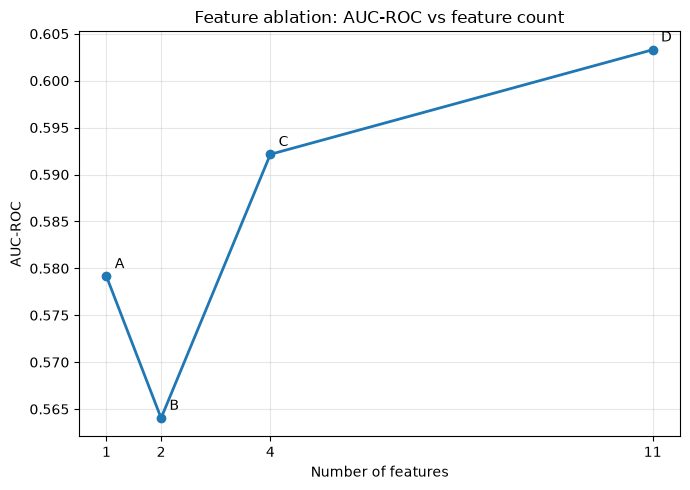

Saved D:\ARGUS\backend\notebooks\feature_ablation_curve.png

1 feature (min_cv_pitch alone) achieves 96.0% of the 11-feature ensemble's AUC-ROC (0.5791 / 0.6033).

Marginal AUC gain 1 -> 2 features:  -0.0151
Marginal AUC gain 2 -> 4 features:  +0.0281
Marginal AUC gain 4 -> 11 features: +0.0111

Smallest marginal gain step: 4->11 -- returns diminish most clearly there.


In [6]:
import matplotlib.pyplot as plt

print(f"{'config':<8} {'n_features':>10} {'AUC-ROC':>10}  features")
print("-" * 90)
for r in results:
    feat_str = ", ".join(r["features"]) if r["n_features"] <= 4 else f"{r['n_features']} features (all)"
    print(f"{r['config']:<8} {r['n_features']:>10} {r['auc']:>10.4f}  {feat_str}")

n_features_list = [r["n_features"] for r in results]
auc_list = [r["auc"] for r in results]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_features_list, auc_list, marker="o", linewidth=2)
for r in results:
    ax.annotate(r["config"], (r["n_features"], r["auc"]),
                textcoords="offset points", xytext=(6, 6))
ax.set_xlabel("Number of features")
ax.set_ylabel("AUC-ROC")
ax.set_title("Feature ablation: AUC-ROC vs feature count")
ax.set_xticks(n_features_list)
ax.grid(alpha=0.3)
fig.tight_layout()

curve_path = Path("feature_ablation_curve.png")
fig.savefig(curve_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {curve_path.resolve()}")

auc_a = results[0]["auc"]
auc_full = results[-1]["auc"]
pct_captured = 100 * auc_a / auc_full

print()
print(f"1 feature (min_cv_pitch alone) achieves {pct_captured:.1f}% of the "
      f"11-feature ensemble's AUC-ROC ({auc_a:.4f} / {auc_full:.4f}).")

gain_a_to_b = results[1]["auc"] - results[0]["auc"]
gain_b_to_c = results[2]["auc"] - results[1]["auc"]
gain_c_to_d = results[3]["auc"] - results[2]["auc"]

print()
print(f"Marginal AUC gain 1 -> 2 features:  {gain_a_to_b:+.4f}")
print(f"Marginal AUC gain 2 -> 4 features:  {gain_b_to_c:+.4f}")
print(f"Marginal AUC gain 4 -> 11 features: {gain_c_to_d:+.4f}")

gains = {"1->2": gain_a_to_b, "2->4": gain_b_to_c, "4->11": gain_c_to_d}
smallest_gain_step = min(gains, key=lambda k: abs(gains[k]))
print(f"\nSmallest marginal gain step: {smallest_gain_step} -- returns diminish most clearly there.")

## Correlation check: Config A (1-feature) scores vs full 11-feature ensemble scores

In [7]:
models = load_models()
test_df = pd.DataFrame(X_test, columns=FEATURE_ORDER)
full_scores = score_players(test_df, models=models)["ensemble_score"].values

# Config A's raw IF scores, normalized 0-1 the same way as elsewhere for
# a fair correlation comparison against the normalized full ensemble score.
scores_a_min, scores_a_max = scores_a.min(), scores_a.max()
scores_a_norm = (scores_a - scores_a_min) / (scores_a_max - scores_a_min)

corr = np.corrcoef(scores_a_norm, full_scores)[0, 1]

print(f"Correlation between Config A (1-feature, min_cv_pitch only) scores "
      f"and the full 11-feature ensemble scores: {corr:.4f}")

if corr > 0.8:
    interp = ("HIGH correlation -- the full model's behavior is largely "
               "redundant with min_cv_pitch alone; the other 10 features "
               "barely change which players get flagged.")
else:
    interp = ("LOWER correlation -- even though the AUCs are close, the "
               "other features meaningfully change WHICH players get "
               "flagged, even if they don't move the AUC much.")

print(f"Interpretation: {interp}")

Correlation between Config A (1-feature, min_cv_pitch only) scores and the full 11-feature ensemble scores: 0.6405
Interpretation: LOWER correlation -- even though the AUCs are close, the other features meaningfully change WHICH players get flagged, even if they don't move the AUC much.
